In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import xgboost as xgb
import xgboost as xgb
import sklearn as sk

In [2]:
tickers = yf.Tickers('MSFT AAPL GOOG')
yf.download(['MSFT', 'AAPL', 'GOOG'], period='1mo')

[*********************100%***********************]  3 of 3 completed


Price            Close                                High              \
Ticker            AAPL        GOOG        MSFT        AAPL        GOOG   
Date                                                                     
2026-08-17  305.589996  341.228485  479.447449  307.660004  344.826125   
2026-08-18  310.029999  341.058563  480.725037  311.489990  342.167859   
2026-08-19  316.829987  341.478333  483.399994  319.279999  343.337111   
2026-08-20  311.299988  337.980591  481.149994  320.279999  340.578880   
2026-08-21  309.350006  341.528259  483.239990  312.380005  343.067269   
2026-08-24  310.339996  344.366425  487.309998  313.359985  347.854150   
2026-08-25  309.899994  343.117249  491.709991  313.589996  346.475085   
2026-08-26  313.450012  338.880005  496.369995  315.429993  342.968354   
2026-08-27  314.579987  337.490875  505.059998  315.399994  338.590168   
2026-08-28  319.700012  342.657532  513.530029  322.369995  345.205865   
2026-08-31  316.850006  335.192383  507.290009  321.239990  340.408997   
2026-09-01  325.130005  331.814575  501.019989  327.299988  333.733343   
2026-09-02  324.959991  333.563446  496.820007  328.399994  336.291686   
2026-09-03  328.209991  338.859985  510.119995  330.809998  340.628856   
2026-09-04  319.970001  335.309998  499.700012  328.929993  340.179993   
2026-09-08  316.220001  335.380005  493.950012  320.700012  336.480011   
2026-09-09  315.339996  328.380005  491.649994  319.149994  329.339996   
2026-09-10  326.570007  330.390015  492.440002  326.739990  330.890015   
2026-09-11  332.269989  335.450012  495.630005  336.220001  339.950012   
2026-09-14  333.079987  345.709991  505.410004  335.500000  346.450012   
2026-09-15  331.339996  341.429993  497.119995  331.779999  344.359985   
2026-09-16  332.410004         NaN  490.299988  335.480011         NaN   

Price                          Low                                Open  \
Ticker            MSFT        AAPL        GOOG        MSFT        AAPL   
Date                                                                     
2026-08-17  491.734316  302.940002  339.349700  477.511091  306.209991   
2026-08-18  483.360060  305.739990  337.300993  476.253443  307.579987   
2026-08-19  488.380608  309.600006  337.830676  478.459283  310.140015   
2026-08-20  484.160004  310.649994  335.951909  479.500000  317.459991   
2026-08-21  486.359985  307.010010  337.590813  478.529999  312.049988   
2026-08-24  490.609985  309.970001  339.399648  481.859985  311.470001   
2026-08-25  492.440002  308.209991  341.923016  484.299988  310.790009   
2026-08-26  497.399994  308.799988  336.791364  487.309998  310.299988   
2026-08-27  506.480011  309.399994  335.182376  490.079987  310.549988   
2026-08-28  517.780029  315.450012  337.061159  504.869995  316.850006   
2026-08-31  512.190002  312.799988  333.213656  506.390015  319.600006   
2026-09-01  505.970001  314.730011  329.076363  496.779999  316.980011   
2026-09-02  500.269989  323.529999  329.306200  493.809998  326.869995   
2026-09-03  515.650024  324.109985  336.091794  500.799988  324.869995   
2026-09-04  511.000000  317.859985  333.750000  499.359985  328.309998   
2026-09-08  495.190002  314.899994  330.390015  490.149994  317.100006   
2026-09-09  494.390015  309.899994  325.630005  489.799988  315.489990   
2026-09-10  494.519989  316.510010  325.651001  486.000000  316.670013   
2026-09-11  498.970001  326.299988  332.549988  492.579987  327.450012   
2026-09-14  509.950012  331.339996  338.739990  495.339996  334.790009   
2026-09-15  505.899994  328.350006  339.179993  495.540009  330.140015   
2026-09-16  495.970001  330.700012         NaN  487.230011  332.529999   

Price                                 Volume                      
Ticker            GOOG        MSFT      AAPL      GOOG      MSFT  
Date                                                              
2026-08-17  343.836777  489.219062  38169300  12606100  29635800  
2026-08-18  339.674452  480.63

In [3]:
ticker = yf.Ticker("MSFT")
df = ticker.history(period="2y")  # 2 years of daily bars
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2024-09-17 00:00:00-04:00,433.383890,434.978692,425.547656,428.382874,18874200,0.0,0.0
2024-09-18 00:00:00-04:00,428.235132,429.249113,423.716517,424.110291,18898000,0.0,0.0
2024-09-19 00:00:00-04:00,434.368306,434.634096,430.105626,431.867798,21706600,0.0,0.0
2024-09-20 00:00:00-04:00,430.420664,432.409239,427.467317,428.500977,55167100,0.0,0.0
2024-09-23 00:00:00-04:00,427.526356,429.672447,423.696866,426.768341,15128900,0.0,0.0


In [4]:
print(df.shape)        # (rows, columns) — rows should be roughly 252 trading days/year
print(df.dtypes)       # confirm Open/High/Low/Close/Volume are numeric, index is a datetime
df.tail()

(501, 7)
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-09-10 00:00:00-04:00,488.320007,494.519989,486.000000,492.440002,16038800,0.0,0.0
2026-09-11 00:00:00-04:00,495.649994,498.970001,492.579987,495.630005,14510500,0.0,0.0
2026-09-14 00:00:00-04:00,497.059998,509.950012,495.339996,505.410004,23091900,0.0,0.0
2026-09-15 00:00:00-04:00,500.059998,505.899994,495.540009,497.119995,17794600,0.0,0.0
2026-09-16 00:00:00-04:00,493.029999,495.970001,487.230011,490.299988,16612700,0.0,0.0


In [5]:
df.isna().sum()

Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [6]:
df = df.dropna(subset=["Close"])

In [7]:
gaps = df.index.to_series().diff().dt.days
gaps[gaps > 4]   # weekends alone cause a 3-day gap (Fri->Mon); flags anything bigger

Series([], Name: Date, dtype: float64)

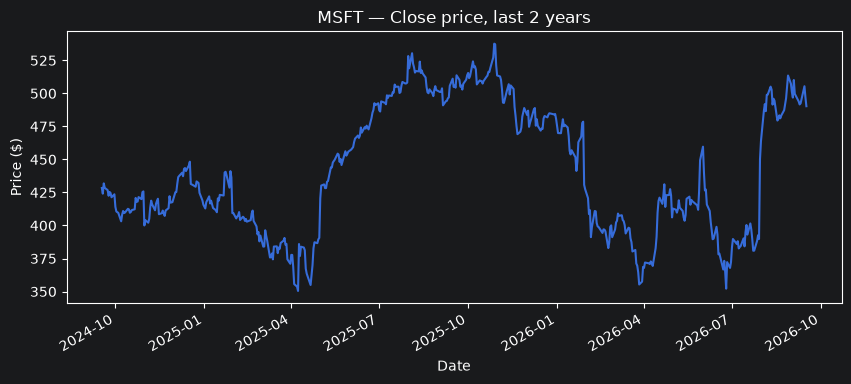

In [8]:
df["Close"].plot(figsize=(10, 4), title="MSFT — Close price, last 2 years")
plt.ylabel("Price ($)")
plt.show()

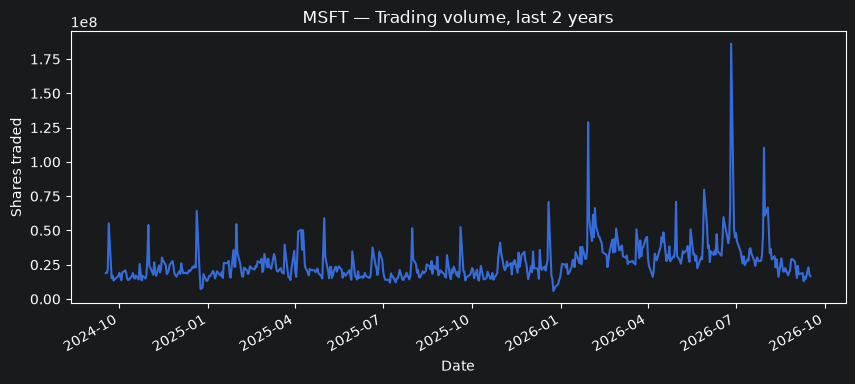

In [9]:
df["Volume"].plot(figsize=(10, 4), title="MSFT — Trading volume, last 2 years")
plt.ylabel("Shares traded")
plt.show()

Feature Engineering

In [10]:
# Creating the close feature
df['return_5d'] = df['Close'].pct_change(periods=5) * 100
df['return_10d'] = df['Close'].pct_change(periods=10) * 100
df['return_20d'] = df['Close'].pct_change(periods=20) * 100

In [11]:
# volume feature
df['Volume_change'] = df['Volume'].pct_change(periods=20) * 100

In [12]:
# Daily gain/loss feature
df['Close_open_diff'] = df['Close'] - df['Open']

In [13]:
# Intraday range as % of close
df['high_low_pct'] = (df['High'] - df['Low']) / df['Close'] * 100

In [14]:
df[['Open', 'High', 'Low', 'Close', 'Volume']].head()

,Open,High,Low,Close,Volume
Date,,,,,
2024-09-17 00:00:00-04:00,433.383890,434.978692,425.547656,428.382874,18874200
2024-09-18 00:00:00-04:00,428.235132,429.249113,423.716517,424.110291,18898000
2024-09-19 00:00:00-04:00,434.368306,434.634096,430.105626,431.867798,21706600
2024-09-20 00:00:00-04:00,430.420664,432.409239,427.467317,428.500977,55167100
2024-09-23 00:00:00-04:00,427.526356,429.672447,423.696866,426.768341,15128900


In [15]:
df['target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

In [16]:
df_clean = df.dropna()

In [17]:
print(df.shape)
print(df_clean.shape)

(501, 14)
(481, 14)


In [18]:
df_clean[['Close', 'target']].tail(10)

,Close,target
Date,,
2026-09-02 00:00:00-04:00,496.820007,1
2026-09-03 00:00:00-04:00,510.119995,0
2026-09-04 00:00:00-04:00,499.700012,0
2026-09-08 00:00:00-04:00,493.950012,0
2026-09-09 00:00:00-04:00,491.649994,1
2026-09-10 00:00:00-04:00,492.440002,1
2026-09-11 00:00:00-04:00,495.630005,1
2026-09-14 00:00:00-04:00,505.410004,0
2026-09-15 00:00:00-04:00,497.119995,0


#The Train/Test Split

In [19]:
split_idx = int(len(df_clean) * 0.8)

train = df_clean.iloc[:split_idx]
test = df_clean.iloc[split_idx:]

feature_cols = ['return_5d', 'return_10d', 'return_20d', 'Volume_change', 'Close_open_diff', 'high_low_pct']

X_train, y_train = train[feature_cols], train['target']
X_test, y_test = test[feature_cols], test['target']

print(train.index.min(), "to", train.index.max())
print(test.index.min(), "to", test.index.max())

2024-10-15 00:00:00-04:00 to 2026-04-28 00:00:00-04:00
2026-04-29 00:00:00-04:00 to 2026-09-16 00:00:00-04:00


# The baseline XGBoost model

In [22]:
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [23]:
print(predictions[:10])
print(predictions.shape)

[1 0 0 1 0 0 1 0 0 0]
(97,)


In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model_accuracy = accuracy_score(y_test, predictions)
naive_baseline = max(y_test.mean(), 1 - y_test.mean())

print(f"Model accuracy:  {model_accuracy:.3f}")
print(f"Naive baseline:  {naive_baseline:.3f}")
print(f"\nConfusion matrix:\n{confusion_matrix(y_test, predictions)}")
print(f"\n{classification_report(y_test, predictions)}")

Model accuracy:  0.526
Naive baseline:  0.505

Confusion matrix:
[[19 29]
 [17 32]]

              precision    recall  f1-score   support

           0       0.53      0.40      0.45        48
           1       0.52      0.65      0.58        49

    accuracy                           0.53        97
   macro avg       0.53      0.52      0.52        97
weighted avg       0.53      0.53      0.52        97



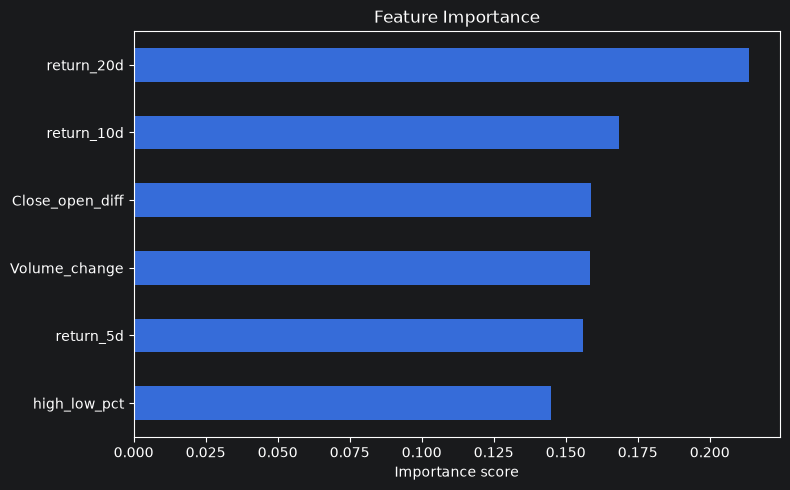

In [25]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importance score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()